# 🏀 Projet NBA — Modélisation, étape 1 : la baseline (dataset NBA_Shots_04_25)

**Objectif de l'étape** (planning DataScientest, échéance du 6 novembre) : construire les premiers modèles simples, les comparer, et établir si l'approche tient : la probabilité qu'un tir rentre peut-elle être estimée à partir de son seul contexte, mieux qu'en prédisant la moyenne ?

**Entrée** : `data/processed/shots_encoded_2015_2025.parquet`, produit par `02_preprocessing.ipynb` : 2 095 638 tirs, 24 variables d'entrée (numériques ou 0/1), une cible `SHOT_MADE`, une colonne `split` (train / validation / test) et des clés (`shot_id`, `PLAYER_ID`…) qui ne servent jamais au modèle.

**Sorties** : le modèle de référence de la baseline dans `models/`, les prédictions sur la validation dans `data/processed/`, les figures dans `output/figures/` (préfixe `M`), le compte rendu dans `output/modelisation.md`.

**Hors périmètre de ce notebook**, conformément au planning : réglage des paramètres et forêt aléatoire (décembre), boosting, deep learning et interprétabilité SHAP (février), comparaison réel − attendu par joueur (notebook ultérieur).

Format : une cellule d'explication avant chaque bloc, du code pandas / scikit-learn commenté, une cellule « Lecture » après.

## 0. Charger la table et contrôler les variables d'entrée

La liste des 24 colonnes d'entrée est écrite explicitement : c'est la garantie du cadrage (modèle neutre, sans l'identité du joueur). Un contrôle vérifie qu'aucune clé n'y figure et que la liste correspond exactement à « toutes les colonnes moins les clés et la cible ».

Le jeu `test` (saison 2024-25) est **scellé** : aucune variable n'est créée pour lui. Il ne sera utilisé qu'à l'évaluation finale, une seule fois.

In [1]:
import json
import time                                   # mesure du temps d'entraînement de chaque modèle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib                                 # sauvegarde / rechargement d'un modèle scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve

DATA   = Path("..") / "data" / "processed"                  # table produite par 02_preprocessing
MODELS = Path("..") / "models"                              # modèles sauvegardés
FIG    = Path("..") / "output" / "figures"                  # figures de ce notebook (préfixe M)
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

table = pd.read_parquet(DATA / "shots_encoded_2015_2025.parquet")
print(f"{table.shape[0]:,} tirs × {table.shape[1]} colonnes".replace(",", " "))

2 095 638 tirs × 30 colonnes


In [2]:
cles  = ["shot_id", "saison_debut", "GAME_ID", "PLAYER_ID", "split"]   # clés : retrouver / filtrer, jamais en entrée du modèle
cible = "SHOT_MADE"

# Les 24 variables d'entrée (cadrage : rien qui identifie le joueur, l'équipe ou le match)
features = [
    # position et nature du tir
    "SHOT_DISTANCE", "LOC_X", "LOC_Y", "tir_3pts",
    # moment du match
    "QUARTER", "prolongation", "temps_restant_qt", "temps_restant_match",
    # contexte
    "tireur_domicile",
    # zone du terrain (one-hot, 6 modalités)
    "BASIC_ZONE_Above the Break 3", "BASIC_ZONE_In The Paint (Non-RA)", "BASIC_ZONE_Left Corner 3",
    "BASIC_ZONE_Mid-Range", "BASIC_ZONE_Restricted Area", "BASIC_ZONE_Right Corner 3",
    # famille de geste (one-hot, 5 modalités)
    "type_geste_Dunk", "type_geste_Floater", "type_geste_Hook", "type_geste_Jump shot", "type_geste_Layup",
    # poste du tireur (one-hot, 4 modalités)
    "POSITION_GROUP_C", "POSITION_GROUP_F", "POSITION_GROUP_G", "POSITION_GROUP_Inconnu",
]

def controle(nom, condition):
    """Affiche ok ou ko devant le nom du contrôle (même fonction que dans le pre-processing)."""
    print(("ok" if condition else "ko"), nom)

controle("24 variables d'entrée",                                  len(features) == 24)
controle("aucune clé ni cible parmi les variables d'entrée",       not set(features) & set(cles + [cible]))
controle("variables = toutes les colonnes moins clés et cible",    set(features) == set(table.columns) - set(cles + [cible]))
controle("aucune valeur manquante",                                table[features + [cible]].isna().sum().sum() == 0)

# Découpage : colonne split du pre-processing. Le test n'est pas chargé dans une variable.
train = table[table["split"] == "train"]
val   = table[table["split"] == "validation"]
X_train, y_train = train[features], train[cible]
X_val,   y_val   = val[features],   val[cible]
del train, val

print()
print(f"train      : {len(X_train):>9,} tirs (saisons 2015-16 → 2022-23), réussite {y_train.mean()*100:.1f} %".replace(",", " "))
print(f"validation : {len(X_val):>9,} tirs (saison 2023-24),             réussite {y_val.mean()*100:.1f} %".replace(",", " "))
print(f"test       : {(table['split'] == 'test').sum():>9,} tirs (saison 2024-25) — scellé, non chargé".replace(",", " "))

ok 24 variables d'entrée
ok aucune clé ni cible parmi les variables d'entrée
ok variables = toutes les colonnes moins clés et cible
ok aucune valeur manquante

train      : 1 658 384 tirs (saisons 2015-16 → 2022-23)  réussite 46.3 %
validation :   218 254 tirs (saison 2023-24)              réussite 47.5 %
test       :   219 000 tirs (saison 2024-25) — scellé  non chargé


**Lecture.** Les quatre contrôles passent : le modèle ne reçoit que les 24 colonnes du cadrage. Le train compte 1,66 million de tirs, la validation 218 000. Les taux de réussite sont voisins (46,3 % et 47,5 %) : la saison 2023-24 est représentative et convient comme jeu de validation.

## 1. Panorama des modèles : choix et calendrier

Le problème est une **classification supervisée binaire** : la cible `SHOT_MADE` vaut 0 ou 1 et elle est connue pour chaque tir. Particularité : la sortie attendue est la **probabilité** de réussite (`predict_proba`), pas seulement la classe. Familles classiques et décision pour chacune :

| Famille | Principe | Étape | Décision |
|---|---|---|---|
| Prédire la moyenne | 46,3 % pour tout tir | **ici** (plancher) | niveau zéro à battre ; ce n'est pas un modèle |
| Régression logistique | somme pondérée des 24 colonnes, passée dans une fonction logistique | **ici** (baseline) | modèle le plus simple qui apprend ; poids interprétables |
| Arbre de décision | suite de questions oui/non sur les colonnes | **ici** | représentable graphiquement ; montre les colonnes utilisées en premier |
| Forêt aléatoire | vote de nombreux arbres | décembre | ensemble (*bagging*), étape « modèles plus complexes » |
| Gradient boosting | arbres corrigeant successivement les erreurs | février | ensemble (*boosting*), le plus performant sur ce type de données |
| Réseau de neurones | couches de sommes pondérées et de non-linéarités | février | deep learning, étape avancée |
| SVM | frontière à marge maximale | écarté | coût prohibitif sur 1,66 M de lignes |
| k plus proches voisins | tirs les plus ressemblants | écarté | lent ; inadapté au mélange de distances et de colonnes 0/1 |
| Naïf bayésien | variables supposées indépendantes | écarté | `SHOT_DISTANCE`, `LOC_X`, `LOC_Y`, `BASIC_ZONE` sont fortement redondantes |

Chaque modèle retenu doit pouvoir être expliqué au jury ; le nombre de modèles est limité en conséquence.

## 2. Métriques d'évaluation

Deux notions distinctes :

- la **fonction de coût** est ce que le modèle **minimise pendant l'apprentissage**. Elle est propre à chaque algorithme : la régression logistique minimise le *log-loss*, l'arbre de décision minimise une impureté (Gini) à chaque coupure ;
- la **métrique d'évaluation** est le critère **choisi** pour juger le modèle après apprentissage, sur `validation`.

L'*accuracy* (taux de bonnes réponses) n'est pas retenue comme critère principal : elle exige de transformer la probabilité en classe par un seuil (0,5) alors que le cadrage demande la probabilité ; elle ne distingue pas une prédiction de 0,51 d'une prédiction de 0,95 quand le tir rentre ; et un tir est incertain par nature (un tir « à 60 % » rate quatre fois sur dix même pour un modèle parfait), donc l'*accuracy* reste basse sans renseigner sur la justesse de la probabilité.

Métriques retenues :

| Métrique | Question | Lecture |
|---|---|---|
| **log-loss** (principale) | la probabilité prédite est-elle juste ? pénalise fortement une prédiction confiante et fausse | plus bas = mieux |
| **AUC** (complément) | les tirs réussis sont-ils classés devant les ratés ? | 0,5 = hasard, 1 = parfait |
| **courbe de calibration** (visuelle) | les tirs prédits à 40 % rentrent-ils à 40 % ? | proche de la diagonale = bien |

L'*accuracy* est affichée dans les tableaux à titre d'information. L'exemple ci-dessous illustre la différence entre les deux critères.

In [3]:
# Cinq tirs au résultat connu (1 = rentré), et deux modèles qui donnent une probabilité pour chacun
reel      = np.array([1,    1,    0,    0,    1])
prudent   = np.array([0.70, 0.60, 0.30, 0.60, 0.70])        # modèle A : probabilités modérées, erreur sur le 4e tir (0,60 alors que raté)
confiant  = np.array([0.95, 0.90, 0.10, 0.97, 0.95])        # modèle B : probabilités tranchées, même erreur sur le 4e tir (0,97)

for nom, p in [("A prudent ", prudent), ("B confiant", confiant)]:
    classe = (p >= 0.5).astype(int)                          # seuil 0,5 pour l'accuracy
    print(f"modèle {nom} : accuracy = {accuracy_score(reel, classe):.2f}   log-loss = {log_loss(reel, p):.3f}")

modèle A prudent  : accuracy = 0.80   log-loss = 0.499
modèle B confiant : accuracy = 0.80   log-loss = 0.764


**Lecture.** Les deux modèles ont la **même accuracy** (quatre bonnes réponses sur cinq, la même erreur sur le 4e tir) mais le modèle confiant a un log-loss nettement plus élevé, 0,76 contre 0,50 : une probabilité de 97 % sur un tir raté est lourdement pénalisée. C'est le comportement attendu d'un critère destiné à juger une probabilité affichée à un utilisateur.

In [4]:
resultats = []                                               # une ligne par modèle évalué, pour le tableau final

def evaluer(nom, proba, y=None, duree=None):
    """Calcule les métriques d'un vecteur de probabilités sur la validation, les affiche et les range dans `resultats`."""
    y = y_val if y is None else y
    ligne = {"modèle": nom,
             "log-loss": round(log_loss(y, proba), 4),
             "AUC": round(roc_auc_score(y, proba), 4),
             "accuracy (seuil 0,5)": round(accuracy_score(y, (proba >= 0.5).astype(int)), 4),
             "temps (s)": None if duree is None else round(duree, 1)}
    resultats.append(ligne)
    print(f"{nom:34s} log-loss = {ligne['log-loss']:.4f}   AUC = {ligne['AUC']:.4f}   accuracy = {ligne['accuracy (seuil 0,5)']:.4f}"
          + ("" if duree is None else f"   ({duree:.0f} s)"))
    return ligne

## 3. Plancher : prédiction constante

Prédiction constante égale à la moyenne du train, 46,3 %, pour tout tir, sans regarder aucune colonne. Son log-loss sur la validation est la référence à battre : un modèle qui ne fait pas mieux n'a rien appris.

In [5]:
p_plancher = np.full(len(y_val), y_train.mean())              # la même probabilité pour les 218 254 tirs de validation
evaluer("plancher : moyenne du train", p_plancher);

plancher : moyenne du train        log-loss = 0.6922   AUC = 0.5000   accuracy = 0.5247


**Lecture.** Log-loss du plancher : **0,692**. AUC 0,5 : une probabilité constante ne classe rien. L'accuracy vaut 52,5 %, soit la part de tirs ratés dans la validation : prédire « raté » partout obtient ce score sans aucune information, ce qui confirme que l'accuracy n'est pas un critère adapté ici.

## 4. Vérification du découpage par saison

La méthode classique, `train_test_split`, mélange toutes les lignes et en met une partie de côté au hasard ; elle suppose les lignes interchangeables. Ici chaque tir a une date, et le jeu évolue : la part de tirs à 3 points passe de 35,6 % dans le train à 42 % en 2024-25. Avec un tirage au hasard, le modèle serait jugé sur des tirs des saisons qu'il a apprises ; en usage réel il reçoit des tirs de saisons jamais vues.

Vérification : le **même** modèle rapide (régression logistique) est évalué de deux façons, sur un jeu mis de côté de même taille. Tirage au hasard parmi les saisons 2015-16 → 2023-24, ou découpage par saison (`split`). Ce n'est pas un problème de série temporelle : aucune date n'entre dans le modèle ; la date sert seulement à répartir les lignes entre apprentissage et évaluation.

In [6]:
modele_rapide = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# (a) Tirage au hasard : train + validation mélangés, autant de tirs mis de côté que la validation en compte
pool = table[table["split"].isin(["train", "validation"])]
X_a, X_b, y_a, y_b = train_test_split(pool[features], pool[cible], test_size=len(X_val), random_state=0)
ll_hasard = log_loss(y_b, modele_rapide.fit(X_a, y_a).predict_proba(X_b)[:, 1])
del pool, X_a, X_b, y_a, y_b

# (b) Découpage par saison : train = 2015-16 → 2022-23, évaluation = 2023-24
ll_saison = log_loss(y_val, modele_rapide.fit(X_train, y_train).predict_proba(X_val)[:, 1])

print(f"log-loss, tirage au hasard      : {ll_hasard:.4f}")
print(f"log-loss, découpage par saison  : {ll_saison:.4f}")
print(f"écart                           : {ll_saison - ll_hasard:+.4f}  (positif = le découpage par saison est plus sévère)")

log-loss, tirage au hasard      : 0.6490
log-loss, découpage par saison  : 0.6497
écart                           : +0.0007  (positif = le découpage par saison est plus sévère)


**Lecture.** Tirage au hasard 0,6490, découpage par saison 0,6497 : l'écart est dans le sens attendu (le tirage au hasard est plus favorable parce qu'il juge le modèle sur un passé déjà vu) mais **petit** (0,0007). Pour ce modèle et cette fenêtre 2015-2024, la dérive du jeu coûte peu. Le découpage par saison est conservé pour l'ensemble du projet : il est le seul à reproduire l'usage réel, et son coût est négligeable ici. L'écart sera re-mesuré avec les modèles plus complexes de décembre, susceptibles de sur-apprendre une époque.

## 5. Baseline : régression logistique

**Principe.** Chaque colonne reçoit un poids. La prédiction est la somme pondérée des 24 colonnes, passée dans la fonction logistique qui ramène le résultat entre 0 et 1. L'apprentissage consiste à trouver les 24 poids qui minimisent le log-loss sur le train.

**Standardisation.** Les colonnes n'ont pas la même échelle : `temps_restant_match` va de 0 à 2 880, `tir_3pts` vaut 0 ou 1. Sans mise à l'échelle, l'algorithme converge mal et les poids ne sont pas comparables. `StandardScaler` ramène chaque colonne à moyenne 0 et écart-type 1. Il est **ajusté sur le train seulement** : le `Pipeline` fait le `fit` sur train, puis applique la même transformation à la validation, ce qui évite toute fuite de la validation dans l'apprentissage. Le pre-processing n'a pas standardisé, parce que l'arbre de décision n'en a pas besoin.

**Lecture des poids.** Un poids positif augmente la probabilité, un poids négatif la diminue ; les colonnes étant standardisées, les poids se comparent entre eux.

régression logistique              log-loss = 0.6497   AUC = 0.6423   accuracy = 0.6225   (1 s)


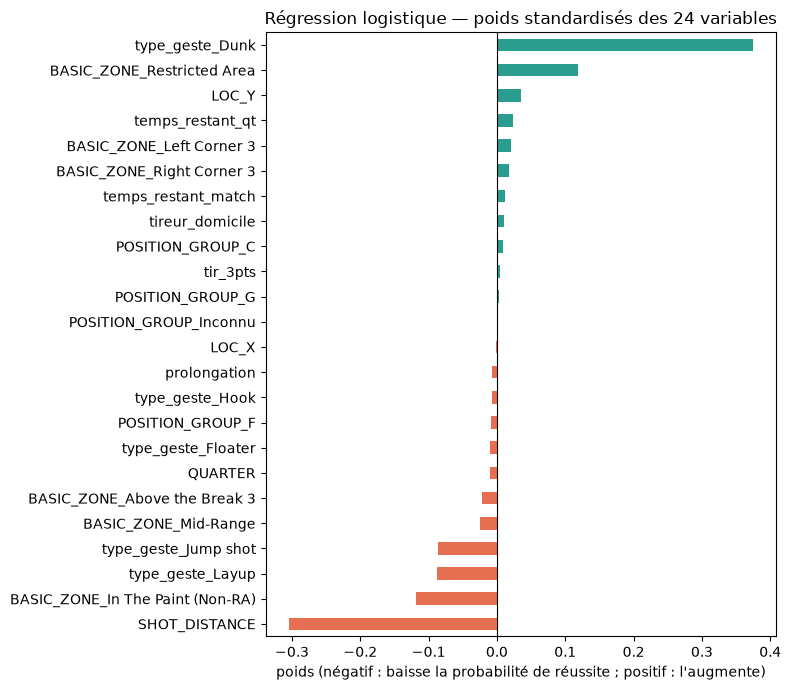

SHOT_DISTANCE                      -0.305
BASIC_ZONE_In The Paint (Non-RA)   -0.119
type_geste_Layup                   -0.088
type_geste_Jump shot               -0.087
BASIC_ZONE_Mid-Range               -0.025
BASIC_ZONE_Above the Break 3       -0.022
QUARTER                            -0.010
type_geste_Floater                 -0.010
POSITION_GROUP_F                   -0.009
type_geste_Hook                    -0.008
prolongation                       -0.007
LOC_X                              -0.001
POSITION_GROUP_Inconnu             -0.000
POSITION_GROUP_G                    0.002
tir_3pts                            0.004
POSITION_GROUP_C                    0.008
tireur_domicile                     0.011
temps_restant_match                 0.012
BASIC_ZONE_Right Corner 3           0.018
BASIC_ZONE_Left Corner 3            0.021
temps_restant_qt                    0.024
LOC_Y                               0.036
BASIC_ZONE_Restricted Area          0.119
type_geste_Dunk                   

In [7]:
t0 = time.perf_counter()
reg_log = make_pipeline(StandardScaler(),                              # étape 1 : mise à l'échelle, ajustée sur train
                        LogisticRegression(max_iter=1000))             # étape 2 : le modèle
reg_log.fit(X_train, y_train)
p_reg_log = reg_log.predict_proba(X_val)[:, 1]                        # colonne 1 = probabilité de la classe 1 (tir rentré)
evaluer("régression logistique", p_reg_log, duree=time.perf_counter() - t0)

# Poids (coefficients) triés ; comparables parce que les colonnes sont standardisées
poids = (pd.Series(reg_log[-1].coef_[0], index=features)
           .sort_values())
fig, ax = plt.subplots(figsize=(8, 7))
poids.plot.barh(ax=ax, color=np.where(poids > 0, "#2a9d8f", "#e76f51"))
ax.axvline(0, color="black", lw=0.8); ax.set_title("Régression logistique — poids standardisés des 24 variables")
ax.set_xlabel("poids (négatif : baisse la probabilité de réussite ; positif : l'augmente)")
plt.tight_layout(); plt.savefig(FIG / "M1_poids_regression_logistique.png", dpi=150); plt.show()
print(poids.round(3).to_string())

**Lecture.** La régression logistique bat le plancher : log-loss 0,6497 contre 0,692, AUC 0,642. Le contexte d'un tir contient donc une information exploitable.

Les deux poids dominants sont ceux que l'EDA annonçait : `type_geste_Dunk` (+0,38, le plus fort) et `SHOT_DISTANCE` (−0,31, le plus négatif). Viennent ensuite les zones proches du cercle : `BASIC_ZONE_Restricted Area` (+0,12) et `BASIC_ZONE_In The Paint (Non-RA)` (−0,12). Les colonnes du moment du match, le domicile et le poste ont des poids entre 0,01 et 0,02 : effet réel mais secondaire une fois le geste et la position connus.

Le poids **négatif** de `type_geste_Layup` (−0,09), alors que les layups réussissent à 56 %, s'interprète *à distance et zone égales* : `SHOT_DISTANCE` et `BASIC_ZONE_Restricted Area` portent déjà l'information « près du cercle », et un layup y réussit moins qu'un dunk. `SHOT_DISTANCE`, `LOC_X`, `LOC_Y`, `tir_3pts` et les zones sont redondantes ; leurs poids se partagent l'effet et ne s'interprètent pas isolément. C'est la limite connue d'un modèle linéaire sur des variables redondantes.

## 6. Arbre de décision

**Principe.** Une suite de questions oui/non sur les colonnes (« `type_geste_Dunk` = 1 ? », puis « `SHOT_DISTANCE` ≤ 3 ? »…). Chaque tir descend jusqu'à une feuille, et la probabilité prédite est la part de tirs rentrés parmi les tirs du train tombés dans cette feuille. La standardisation est inutile : une question « ≤ 3 » ne dépend pas de l'échelle.

**Sur-apprentissage.** Sans limite, l'arbre pose des questions jusqu'à isoler chaque tir du train dans sa propre feuille : ses probabilités deviennent 0 ou 1 et son log-loss sur la validation s'effondre. Deux arbres sont comparés : l'arbre libre, puis l'arbre **limité** (profondeur 6, au moins 1 000 tirs par feuille), lisible et généralisable. Le choix fin de la profondeur relève du réglage des paramètres, prévu en décembre.

In [8]:
# (a) Arbre libre : aucune limite de profondeur
t0 = time.perf_counter()
arbre_libre = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
p_libre = arbre_libre.predict_proba(X_val)[:, 1]
evaluer("arbre de décision libre (sur-appris)", p_libre, duree=time.perf_counter() - t0)
print(f"   → profondeur atteinte : {arbre_libre.get_depth()}, feuilles : {arbre_libre.get_n_leaves():,}, "
      f"log-loss sur le TRAIN : {log_loss(y_train, arbre_libre.predict_proba(X_train)[:, 1]):.4f}".replace(",", " "))
del arbre_libre

# (b) Arbre limité : 6 questions au plus, au moins 1 000 tirs du train par feuille
t0 = time.perf_counter()
arbre = DecisionTreeClassifier(max_depth=6, min_samples_leaf=1000, random_state=0).fit(X_train, y_train)
p_arbre = arbre.predict_proba(X_val)[:, 1]
evaluer("arbre de décision (profondeur 6)", p_arbre, duree=time.perf_counter() - t0)
print(f"   → feuilles : {arbre.get_n_leaves()}, log-loss sur le TRAIN : {log_loss(y_train, arbre.predict_proba(X_train)[:, 1]):.4f}")

arbre de décision libre (sur-appris) log-loss = 16.3341   AUC = 0.5421   accuracy = 0.5443   (10 s)
   → profondeur atteinte : 89  feuilles : 574 988  log-loss sur le TRAIN : 0.0070
arbre de décision (profondeur 6)   log-loss = 0.6458   AUC = 0.6432   accuracy = 0.6236   (3 s)
   → feuilles : 55, log-loss sur le TRAIN : 0.6441


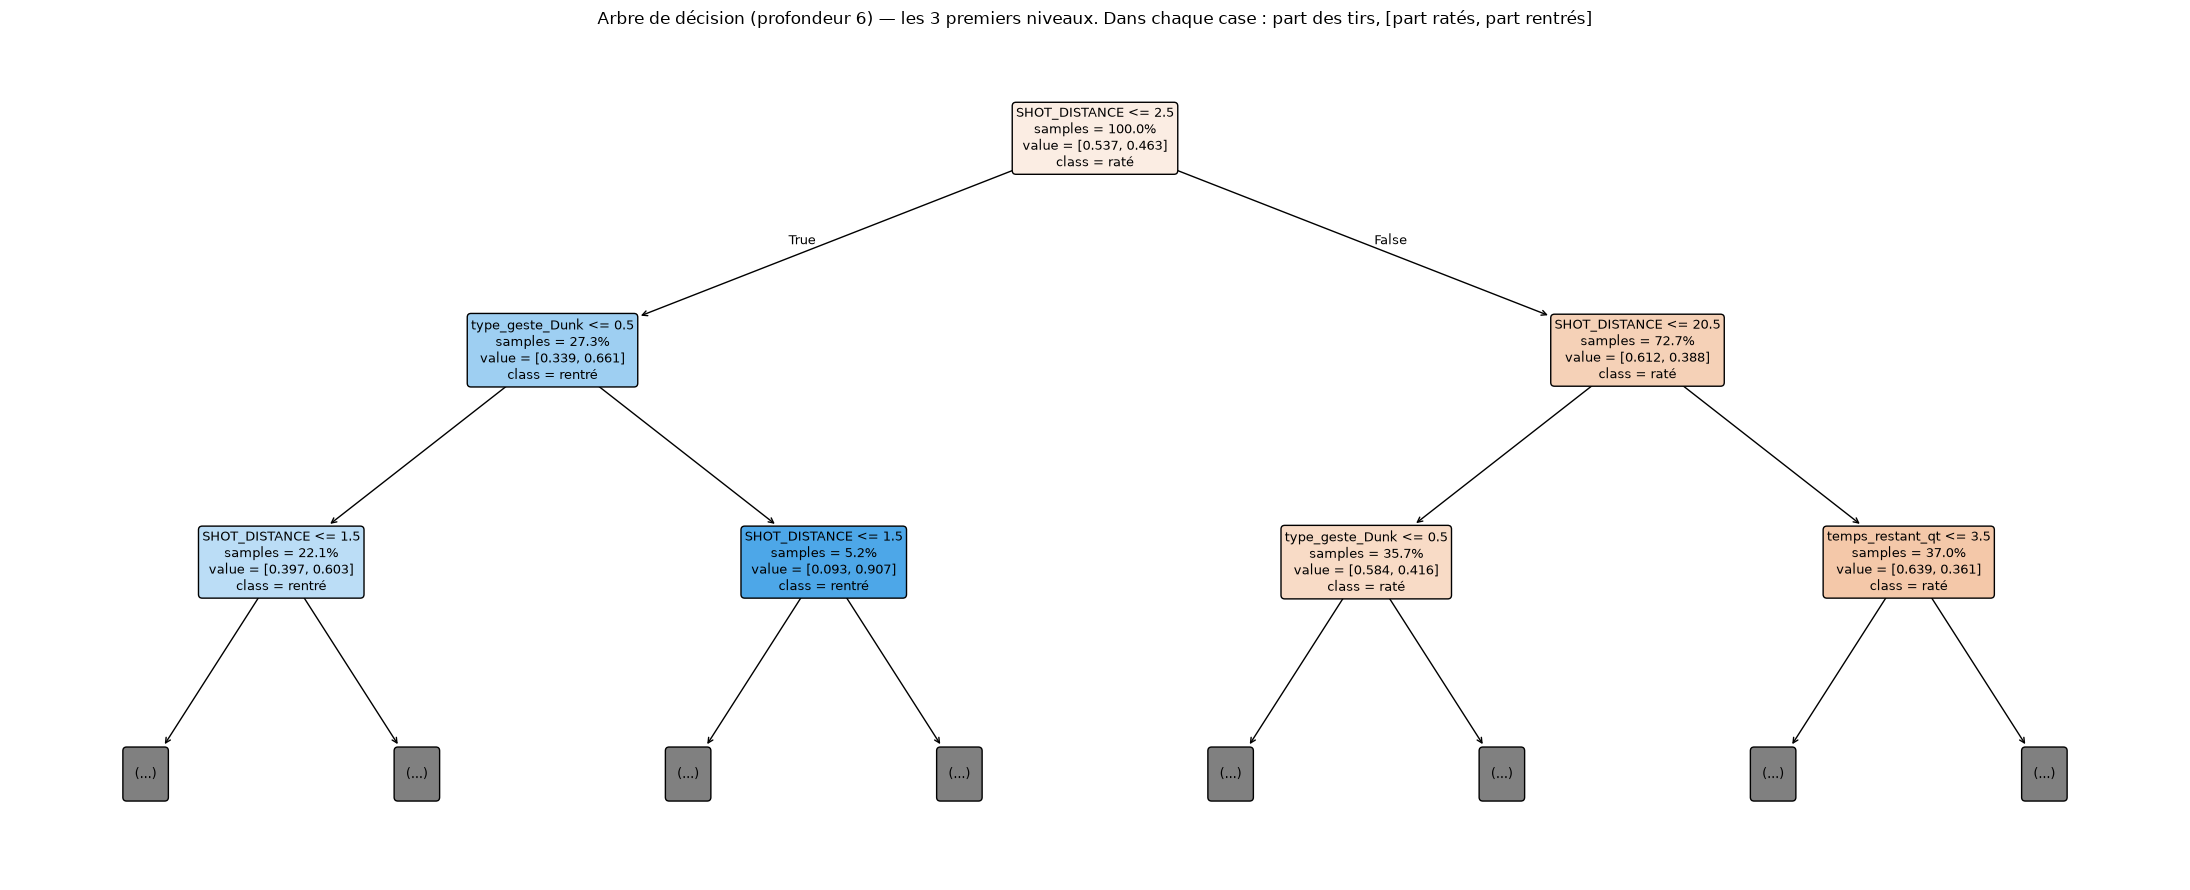

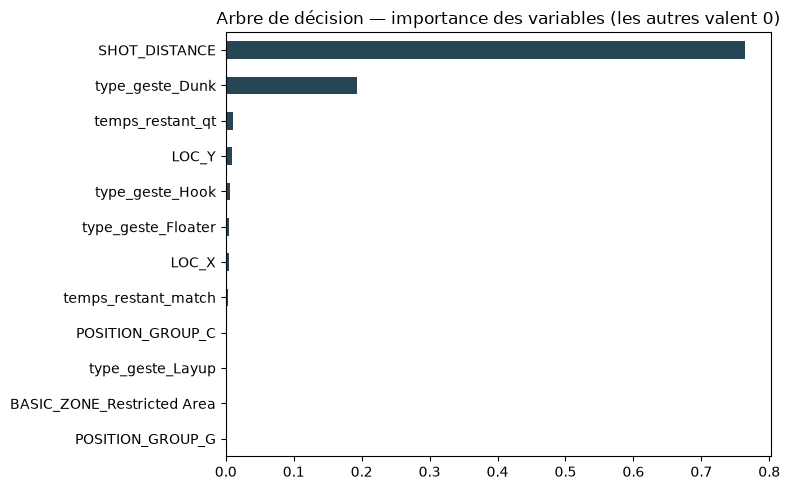

SHOT_DISTANCE                 0.765
type_geste_Dunk               0.193
temps_restant_qt              0.011
LOC_Y                         0.010
type_geste_Hook               0.007
type_geste_Floater            0.005
LOC_X                         0.004
temps_restant_match           0.003
POSITION_GROUP_C              0.001
type_geste_Layup              0.001
BASIC_ZONE_Restricted Area    0.000
POSITION_GROUP_G              0.000


In [9]:
# Les trois premiers niveaux de l'arbre limité
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(arbre, max_depth=2, feature_names=features, class_names=["raté", "rentré"],
          filled=True, proportion=True, rounded=True, fontsize=9, ax=ax, impurity=False)
ax.set_title("Arbre de décision (profondeur 6) — les 3 premiers niveaux. Dans chaque case : part des tirs, [part ratés, part rentrés]")
plt.tight_layout(); plt.savefig(FIG / "M2_arbre_decision.png", dpi=150); plt.show()

# Importance des variables : part des coupures utiles attribuée à chaque colonne
importances = pd.Series(arbre.feature_importances_, index=features).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importances[importances > 0].plot.barh(ax=ax, color="#264653"); ax.invert_yaxis()
ax.set_title("Arbre de décision — importance des variables (les autres valent 0)")
plt.tight_layout(); plt.savefig(FIG / "M3_importances_arbre.png", dpi=150); plt.show()
print(importances[importances > 0].round(3).to_string())

**Lecture.** L'arbre libre descend à 89 niveaux et 575 000 feuilles : log-loss 0,007 sur le train, **16,3** sur la validation. C'est le sur-apprentissage, et la raison pour laquelle un modèle n'est jamais jugé sur les données qu'il a apprises. L'arbre limité à 6 niveaux et 55 feuilles obtient 0,6458 sur la validation et 0,6441 sur le train : pas d'apprentissage par cœur. Il fait **légèrement mieux que la régression logistique** (0,6497).

Ses premières questions correspondent au raisonnement d'un entraîneur. Racine : `SHOT_DISTANCE` ≤ 2,5 pieds, sous le cercle ou non. Sous le cercle, la question suivante est `type_geste_Dunk`, et un dunk tombe dans une case à 91 % de réussite. Loin du cercle, la question suivante est `SHOT_DISTANCE` ≤ 20,5, puis `temps_restant_qt` ≤ 3,5 secondes, les tirs au buzzer. La distance pèse 77 % de l'importance totale, le dunk 19 % : avec six questions, l'arbre consacre son budget aux colonnes les plus discriminantes. Les zones n'apparaissent pas, la distance portant la même information. La forêt aléatoire (décembre) et le boosting (février) exploiteront les variables secondaires.

## 7. Comparaison des modèles

Le tableau rassemble les trois métriques pour chaque modèle. La courbe de calibration répond à la question qui compte pour le produit final : les tirs prédits à 40 % rentrent-ils à 40 % ? Les prédictions sont découpées en dix tranches et, dans chaque tranche, la probabilité moyenne prédite est comparée au taux réel de réussite.

                                      log-loss     AUC  accuracy (seuil 0,5)  temps (s)
modèle                                                                                 
plancher : moyenne du train             0.6922  0.5000                0.5247        NaN
régression logistique                   0.6497  0.6423                0.6225        0.9
arbre de décision libre (sur-appris)   16.3341  0.5421                0.5443        9.9
arbre de décision (profondeur 6)        0.6458  0.6432                0.6236        2.5


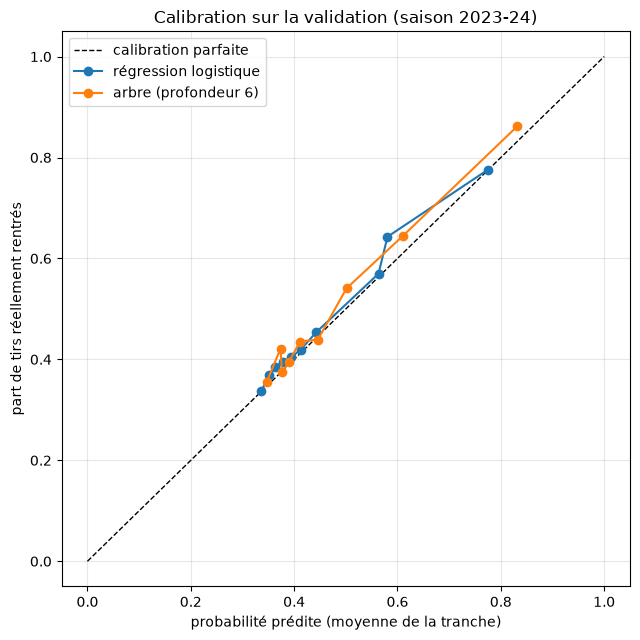

régression logistique    probabilités prédites : min 0.23, médiane 0.40, max 0.91
arbre (profondeur 6)     probabilités prédites : min 0.07, médiane 0.40, max 0.93


In [10]:
tableau = pd.DataFrame(resultats).set_index("modèle")
print(tableau.to_string())

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="calibration parfaite")
for nom, p in [("régression logistique", p_reg_log), ("arbre (profondeur 6)", p_arbre)]:
    reel_moy, pred_moy = calibration_curve(y_val, p, n_bins=10, strategy="quantile")   # 10 tranches de même effectif
    ax.plot(pred_moy, reel_moy, marker="o", label=nom)
ax.set_xlabel("probabilité prédite (moyenne de la tranche)"); ax.set_ylabel("part de tirs réellement rentrés")
ax.set_title("Calibration sur la validation (saison 2023-24)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / "M4_calibration.png", dpi=150); plt.show()

# Étendue des probabilités prédites
for nom, p in [("régression logistique", p_reg_log), ("arbre (profondeur 6)", p_arbre)]:
    print(f"{nom:24s} probabilités prédites : min {p.min():.2f}, médiane {np.median(p):.2f}, max {p.max():.2f}")

**Lecture.** Les deux modèles battent nettement le plancher (0,692) : 0,6497 pour la régression logistique, 0,6458 pour l'arbre limité. Leur courbe de calibration suit la diagonale : les tirs prédits à 60 % rentrent à environ 60 %. **L'approche tient** : le contexte d'un tir permet d'estimer une probabilité de réussite juste, sans information sur le tireur.

L'arbre fait un peu mieux que la régression logistique : avec six questions il combine les variables (« sous le cercle **et** dunk »), ce qu'une somme pondérée ne peut pas exprimer. Il produit aussi des probabilités plus étendues (de 0,07 à 0,93, contre 0,23 à 0,91) en restant calibré. C'est ce qui motive les modèles à base d'arbres prévus en décembre et février.

L'AUC reste modeste, autour de 0,64, et c'est structurel : deux tirs identiques sur les 24 colonnes peuvent avoir deux résultats, aucune colonne ne décrivant la défense. Le modèle estime ce qu'un tir vaut en moyenne, conformément au cadrage ; il ne classe pas ce qu'il ne voit pas.

**Modèle de référence conservé : la régression logistique.** Non pour son score (l'arbre la devance de 0,004) mais parce qu'elle est la baseline au sens du planning : le modèle le plus simple, stable, calibré, dont chaque poids s'explique. L'avance de l'arbre est notée et motive l'étape de décembre.

## 8. Variante avec `saison_debut` : reportée à décembre

Le cadrage prévoit de tester la saison comme variable d'entrée (effet époque : la part de 3 points passe de 35,6 % à 42 % dans la fenêtre). Ce test est reporté à l'étape de décembre, avec le réglage des paramètres, pour que la baseline reste le modèle le plus simple possible et serve de référence stable. La table encodée contient `saison_debut` ; il suffira de l'ajouter à `features`.

## 9. Sauvegarde du modèle de référence

L'application Streamlit ne doit pas ré-entraîner le modèle (consigne du planning) : le `Pipeline` complet, standardisation comprise, est sauvegardé avec la **liste exacte des colonnes** qu'il attend et ses scores. Un rechargement vérifie qu'il prédit un tir à partir d'une ligne de 24 colonnes, comme le fera l'application. Le fichier est remplacé à chaque exécution.

In [11]:
chemin_modele = MODELS / "baseline_regression_logistique.joblib"
joblib.dump({"modele": reg_log,                                        # le Pipeline : StandardScaler + LogisticRegression
             "features": features,                                    # ordre exact des 24 colonnes attendues
             "entrainement": "split == train (saisons 2015-16 → 2022-23)",
             "scores_validation": tableau.loc["régression logistique"].to_dict(),
             "date": pd.Timestamp.today().strftime("%Y-%m-%d")},
            chemin_modele)
print(f"modèle sauvegardé : {chemin_modele}  ({chemin_modele.stat().st_size / 1e3:.0f} ko)")

# Rechargement : un tir de la validation, une ligne de 24 colonnes
charge = joblib.load(chemin_modele)
un_tir = X_val.iloc[[0]][charge["features"]]                              # une ligne, colonnes dans l'ordre attendu
print(f"probabilité prédite pour le premier tir de la validation : {charge['modele'].predict_proba(un_tir)[0, 1]:.3f}  "
      f"(résultat réel : {'rentré' if y_val.iloc[0] == 1 else 'raté'})")
controle("le modèle rechargé prédit comme l'original",
         np.allclose(charge["modele"].predict_proba(X_val.iloc[:1000]), reg_log.predict_proba(X_val.iloc[:1000])))

modèle sauvegardé : ../models/baseline_regression_logistique.joblib  (4 ko)
probabilité prédite pour le premier tir de la validation : 0.903  (résultat réel : rentré)
ok le modèle rechargé prédit comme l'original


### 9.2 Prédictions sur la validation

Le fichier joblib contient le modèle, pas les prédictions. Les probabilités calculées sur la validation sont écrites dans une table, un tir par ligne, reliée aux autres tables par `shot_id`, pour les analyses ultérieures sans ré-exécution de ce notebook : par joueur (réel − attendu), par zone, par moment du match.

In [12]:
predictions = pd.DataFrame({
    "shot_id":       table.loc[X_val.index, "shot_id"].values,      # clé commune avec shots_clean et shots_encoded
    "SHOT_MADE":     y_val.values,                                    # résultat réel
    "proba_reg_log": p_reg_log.round(4),                              # probabilité prédite par la régression logistique
    "proba_arbre":   p_arbre.round(4),                                # probabilité prédite par l'arbre limité
})
chemin_pred = DATA / "predictions_validation_baseline.parquet"
predictions.to_parquet(chemin_pred, index=False)
print(f"{chemin_pred}  —  {chemin_pred.stat().st_size / 1e6:.1f} Mo  —  {len(predictions):,} tirs × {predictions.shape[1]} colonnes".replace(",", " "))

# Contrôle de cohérence globale : moyenne des probabilités prédites contre taux réel de réussite
print(f"réussite réelle : {predictions['SHOT_MADE'].mean()*100:.1f} %   "
      f"moyenne prédite : régression {predictions['proba_reg_log'].mean()*100:.1f} %, arbre {predictions['proba_arbre'].mean()*100:.1f} %")
print()
print(predictions.head(5).to_string(index=False))

../data/processed/predictions_validation_baseline.parquet  —  1.7 Mo  —  218 254 tirs × 4 colonnes
réussite réelle : 47.5 %   moyenne prédite : régression 46.0 %, arbre 45.4 %

 shot_id  SHOT_MADE  proba_reg_log  proba_arbre
 1658385          1         0.9035       0.8630
 1658386          0         0.4119       0.3742
 1658387          0         0.5929       0.5157
 1658388          1         0.3531       0.3765
 1658389          1         0.8988       0.7549


**Lecture.** Une table de 218 254 lignes, une par tir de la saison 2023-24, avec la clé `shot_id`, le résultat réel et les deux probabilités. La moyenne prédite est **légèrement inférieure** au taux réel : 46,0 % et 45,4 % contre 47,5 %. Les modèles héritent du taux du train (46,3 %), et la saison 2023-24 a été un peu plus adroite que les huit précédentes. C'est l'effet époque, visible aussi sur la part de 3 points, que la variante `saison_debut` de décembre devra traiter. La jointure avec `shots_clean_2015_2025.parquet` par `shot_id` donne le joueur ou la zone de chaque tir.

## ✅ Bilan de la baseline

### Résultats sur la validation (saison 2023-24)

| Modèle | log-loss | AUC |
|---|---|---|
| Plancher (moyenne du train) | 0,692 | 0,500 |
| Régression logistique | 0,650 | 0,642 |
| Arbre de décision, profondeur 6 | 0,646 | 0,643 |
| Arbre de décision libre | 16,3 | 0,542 |

Calibration des deux modèles limités proche de la diagonale ; tirage au hasard contre découpage par saison : écart de 0,0007 seulement.

### Décisions

| Décision | Référence | Section |
|---|---|---|
| Critère principal : log-loss ; AUC et calibration en complément ; accuracy pour information | cadrage (« probabilité ») | 2 |
| Découpage par saison conservé, vérifié contre le tirage au hasard | pre-processing 5.3 | 4 |
| Standardisation ajustée sur le train seulement, dans un `Pipeline` | — | 5 |
| Arbre limité à la profondeur 6 ; sur-apprentissage de l'arbre libre documenté | — | 6 |
| **Référence conservée : régression logistique**, sauvegardée dans `models/` ; l'arbre limité fait légèrement mieux (0,646), noté pour décembre | — | 7, 9 |
| Variante `saison_debut`, réglage des paramètres, forêt aléatoire : décembre | planning | 8 |

### Points pour le rapport

1. **L'approche tient** : à partir du seul contexte, les modèles battent le plancher et leurs probabilités sont calibrées.
2. **L'AUC modeste est structurelle** : le résultat d'un tir dépend de facteurs absents de la table (défense, fatigue, adresse du jour). Le modèle estime ce qu'un tir vaut, pas ce qu'il va donner.
3. **Le sur-apprentissage est documenté** : l'arbre libre est parfait sur le train et inutilisable sur la validation.

### Étape suivante (11 décembre)

Réglage des paramètres (profondeur de l'arbre, régularisation de la régression), forêt aléatoire, variante avec `saison_debut`. Évaluation sur `validation` ; le `test` reste scellé.